<a href="https://colab.research.google.com/github/marianafreitasc/CicloGuia---Seguran-a-Ciclovi-ria-do-Rio/blob/main/indicadores_seguranca_ips.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('indicadores_seguranca_isp.csv', sep=';', encoding='latin1')

# Corrige problema de encoding na coluna regiao
df['regiao'] = df['regiao'].str.encode('latin1').str.decode('utf-8', errors='replace')
df

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,47,2,1,0,0,0,637,3
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,NaN,26,2,1,0,0,0,473,3
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,NaN,10,1,3,0,0,0,147,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37583,159,3,2026,2026m03,35,4,Cachoeiras de Macacu,3300803,Interior,3,...,5.0,0.0,26,1,0,0,0,0,156,2
37584,165,3,2026,2026m03,33,5,Mangaratiba,3302601,Interior,1,...,13.0,0.0,33,1,0,0,0,0,240,2
37585,166,3,2026,2026m03,33,5,Angra dos Reis,3300100,Interior,2,...,14.0,1.0,91,10,0,0,0,0,744,2
37586,167,3,2026,2026m03,43,5,Paraty,3303807,Interior,0,...,7.0,0.0,25,1,0,0,0,0,259,2


###Analise inicial

In [ ]:
#dimensões do dataset
df.shape

(37588, 65)

In [ ]:
#informações gerais
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37588 entries, 0 to 37587
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cisp                        37588 non-null  int64  
 1   mes                         37588 non-null  int64  
 2   ano                         37588 non-null  int64  
 3   mes_ano                     37588 non-null  object 
 4   aisp                        37588 non-null  int64  
 5   risp                        37588 non-null  int64  
 6   munic                       37588 non-null  object 
 7   mcirc                       37588 non-null  int64  
 8   regiao                      37588 non-null  object 
 9   hom_doloso                  37588 non-null  int64  
 10  lesao_corp_morte            37588 non-null  int64  
 11  latrocinio                  37588 non-null  int64  
 12  cvli                        37588 non-null  int64  
 13  hom_por_interv_policial     375

In [ ]:
# Estatísticas descritivas das principais variáveis
cols_principais = ['hom_doloso', 'cvli', 'letalidade_violenta', 'total_roubos',
                   'total_furtos', 'estupro', 'trafico_drogas', 'registro_ocorrencias']
df[cols_principais].describe()

,hom_doloso,cvli,letalidade_violenta,total_roubos,total_furtos,estupro,trafico_drogas,registro_ocorrencias
count,37588.000000,37588.000000,37588.000000,37588.000000,37588.000000,37588.000000,32942.000000,37588.000000
mean,2.916383,3.039800,3.660902,84.788975,97.235235,2.931228,5.901767,445.302011
std,4.318591,4.433564,5.267490,119.145140,109.407403,3.652202,7.882535,399.884405
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,2.000000,17.000000,0.000000,1.000000,107.000000
50%,1.000000,1.000000,2.000000,29.000000,64.000000,2.000000,3.000000,371.000000
75%,4.000000,4.000000,5.000000,132.000000,139.000000,4.000000,7.000000,665.000000
max,43.000000,43.000000,122.000000,1160.000000,1665.000000,73.000000,194.000000,3185.000000


In [ ]:
# Verificação de valores nulos
print("Colunas com mais valores nulos:")
df.isnull().sum().sort_values(ascending=False).head(15)

Colunas com mais valores nulos:


,0
feminicidio,35122
tentativa_feminicidio,35122
furto_bicicleta,17389
roubo_bicicleta,17389
posse_drogas,4646
cmp,4646
aaapai,4646
apreensao_drogas_sem_autor,4646
apf,4646
cmba,4646


O dataset é muito rico com 37588 registros, cobrindo 24 anos de dados mensais por delegacia com a maior parte das colunas numéricas. O problema são a grande quantidade de dados nulos passando dos 35 mil como no feminicidio que passou a ser registrado a partir de 2016 apenas. o describe() já revela distribuições muito assimétricas em quase todas as variaveis indicando forte presença de outliers

###Analise Univariada

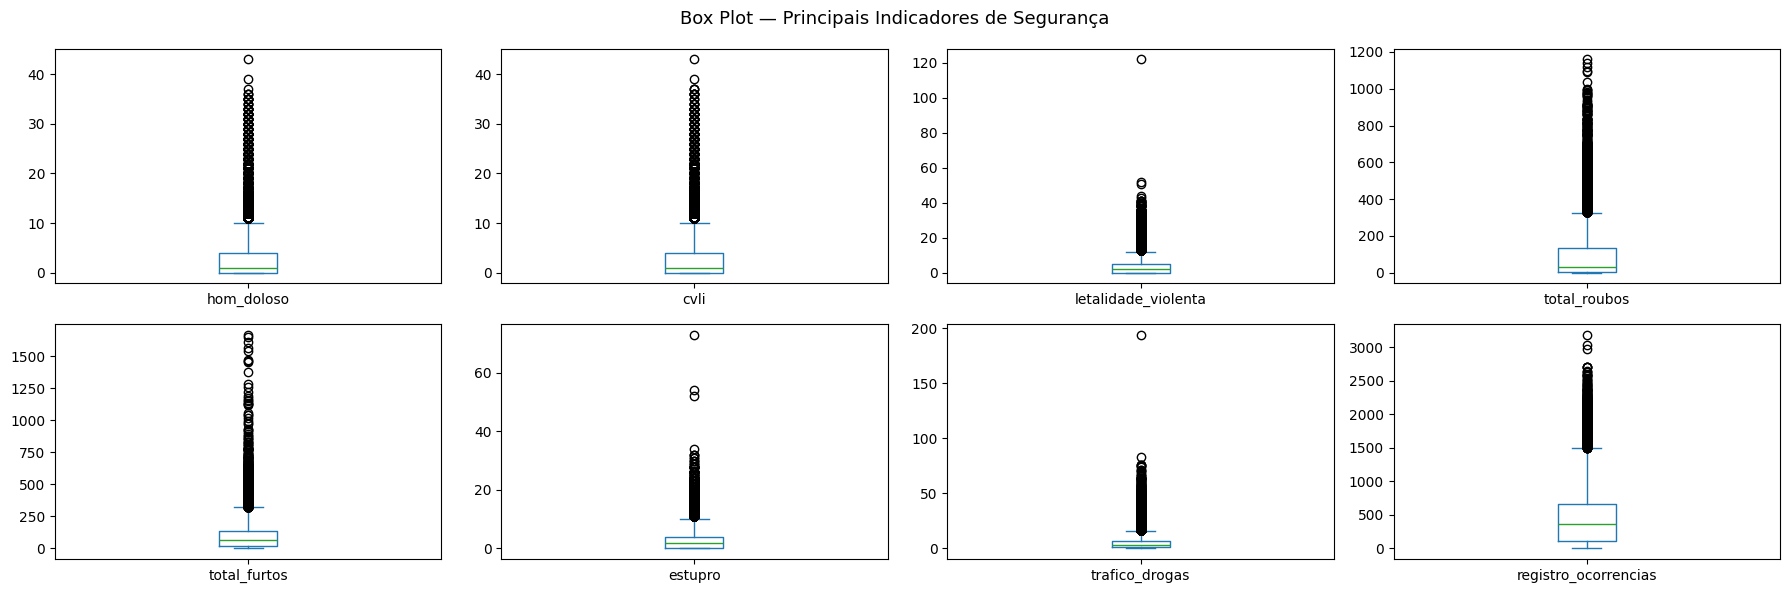

In [ ]:
# Box plot das principais variáveis de crime
df[cols_principais].plot(kind='box', figsize=(18, 6), subplots=True, layout=(2, 4))
plt.suptitle('Box Plot — Principais Indicadores de Segurança', fontsize=13)
plt.tight_layout()
plt.show()

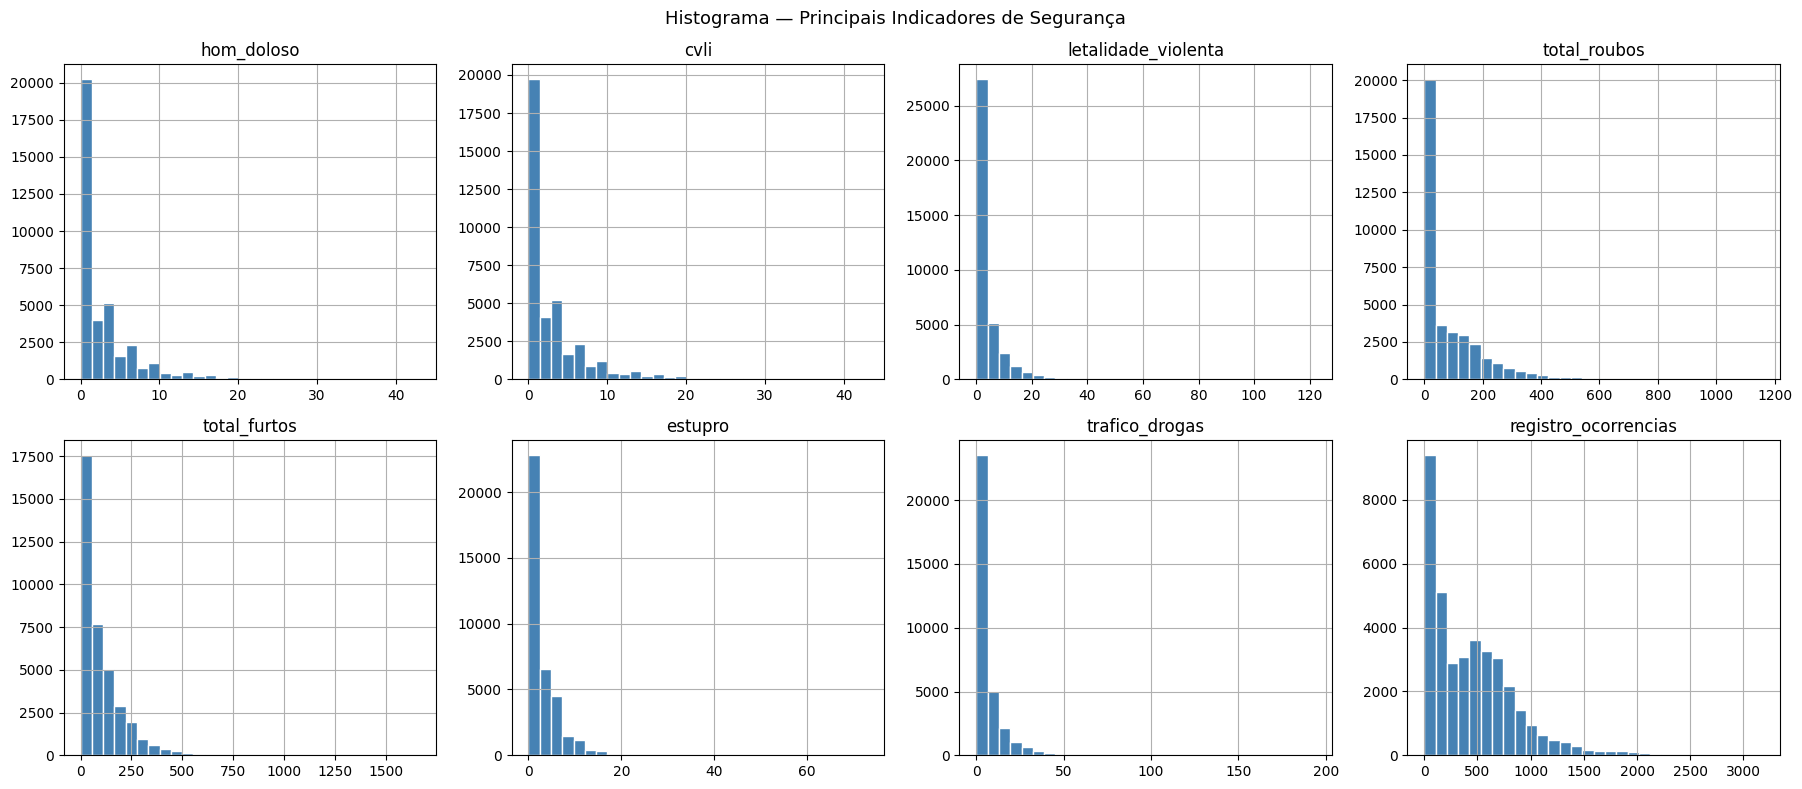

In [ ]:
# Histogramas
df[cols_principais].hist(figsize=(18, 8), layout=(2, 4), bins=30, color='steelblue', edgecolor='white')
plt.suptitle('Histograma — Principais Indicadores de Segurança', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
#quantidade de regiões que aparecem no dataset
print('Regiões disponíveis:')
print(df['regiao'].value_counts())

Regiões disponíveis:
regiao
Interior                 18326
Capital                  11279
Baixada Fluminense        5193
Grande NiterÃÂÃÂ³i     2610
Grande Niter�i             180
Name: count, dtype: int64


/tmp/ipykernel_6850/1030230096.py:8: UserWarning: Glyph 131 (\x83) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6850/1030230096.py:8: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 131 (\x83) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


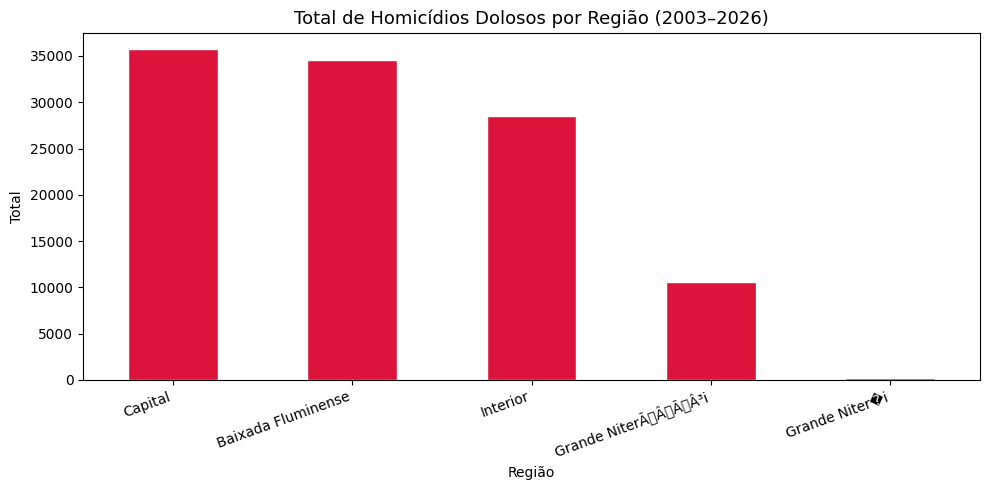

In [ ]:
# Total de homicídios dolosos por região
total_hom_regiao = df.groupby('regiao')['hom_doloso'].sum().sort_values(ascending=False)
total_hom_regiao.plot(kind='bar', figsize=(10, 5), color='crimson', edgecolor='white')
plt.title('Total de Homicídios Dolosos por Região (2003–2026)', fontsize=13)
plt.xlabel('Região')
plt.ylabel('Total')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Top 10 municípios com mais roubos
print('Top 10 municípios com mais roubos (acumulado):')
print(df.groupby('munic')['total_roubos'].sum().sort_values(ascending=False).head(10))

Top 10 municípios com mais roubos (acumulado):
munic
Rio de Janeiro           1825309
Duque de Caxias           252602
São Gonçalo               234881
Nova Iguaçu               172191
São João de Meriti        120406
Niterói                   115368
Belford Roxo               78793
Nilópolis                  50368
Mesquita                   40732
Campos dos Goytacazes      31201
Name: total_roubos, dtype: int64


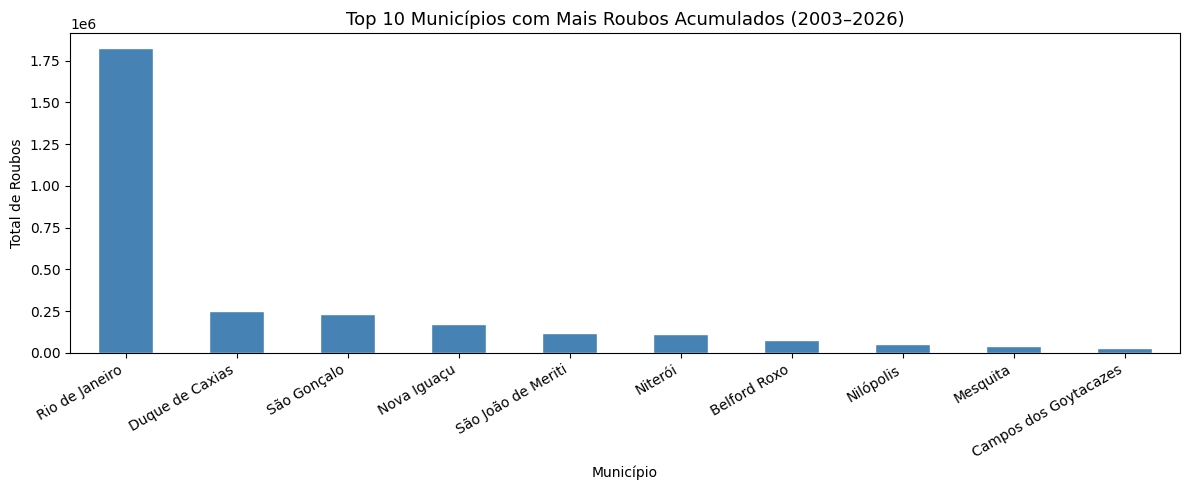

In [ ]:
# Gráfico top 10 municípios
top10_munic = df.groupby('munic')['total_roubos'].sum().sort_values(ascending=False).head(10)
top10_munic.plot(kind='bar', figsize=(12, 5), color='steelblue', edgecolor='white')
plt.title('Top 10 Municípios com Mais Roubos Acumulados (2003–2026)', fontsize=13)
plt.xlabel('Município')
plt.ylabel('Total de Roubos')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Confirmamos com o histograma as fistribuições fortemente assimétricas e um forte número de outliers pelo boxplot. A Capital concentra os maiores índices de roubos e furtos, enquanto a Capital e a Baixada Fluminense apresentam números semelhantes de homicídios dolosos. Entre os municípios, o Rio de Janeiro lidera com grande diferença no total de roubos, seguido por Duque de Caxias e São Gonçalo.

###Analise Multivariada


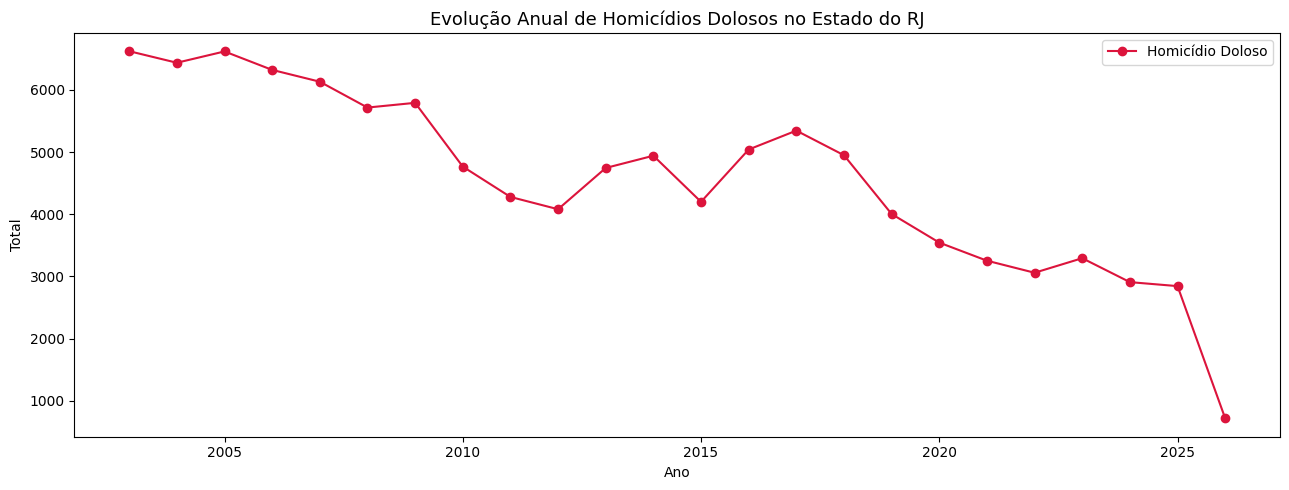

In [ ]:
# Evolução anual de homicídios dolosos
evol = df.groupby('ano')[['hom_doloso', 'total_roubos', 'total_furtos']].sum().reset_index()

plt.figure(figsize=(13, 5))
plt.plot(evol['ano'], evol['hom_doloso'], marker='o', color='crimson', label='Homicídio Doloso')
plt.title('Evolução Anual de Homicídios Dolosos no Estado do RJ', fontsize=13)
plt.xlabel('Ano')
plt.ylabel('Total')
plt.legend()
plt.tight_layout()
plt.show()

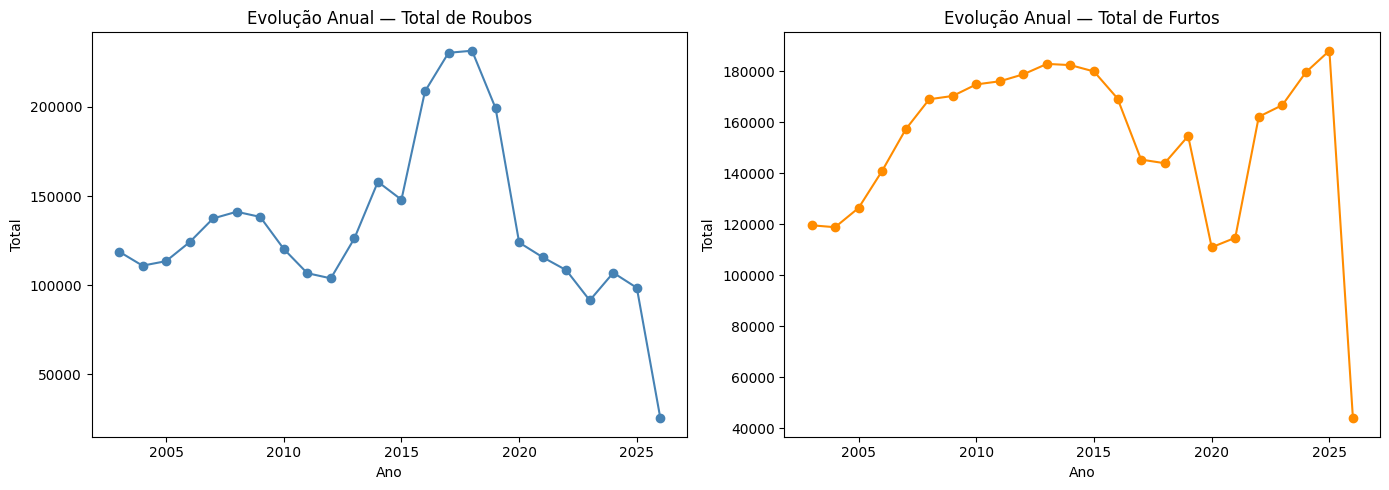

In [ ]:
# Evolução roubos e furtos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(evol['ano'], evol['total_roubos'], marker='o', color='steelblue')
axes[0].set_title('Evolução Anual — Total de Roubos', fontsize=12)
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Total')

axes[1].plot(evol['ano'], evol['total_furtos'], marker='o', color='darkorange')
axes[1].set_title('Evolução Anual — Total de Furtos', fontsize=12)
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Total')

plt.tight_layout()
plt.show()

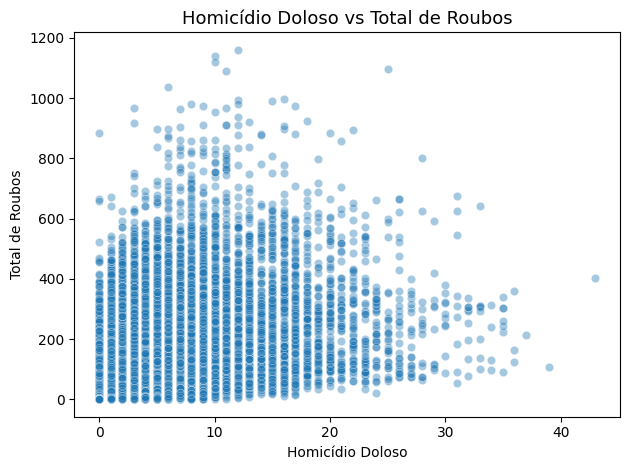

In [ ]:
# Relação entre homicídio doloso e total de roubos
sns.scatterplot(x='hom_doloso', y='total_roubos', data=df, alpha=0.4)
plt.title('Homicídio Doloso vs Total de Roubos', fontsize=13)
plt.xlabel('Homicídio Doloso')
plt.ylabel('Total de Roubos')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6850/3724354250.py:7: UserWarning: Glyph 131 (\x83) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6850/3724354250.py:7: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 131 (\x83) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


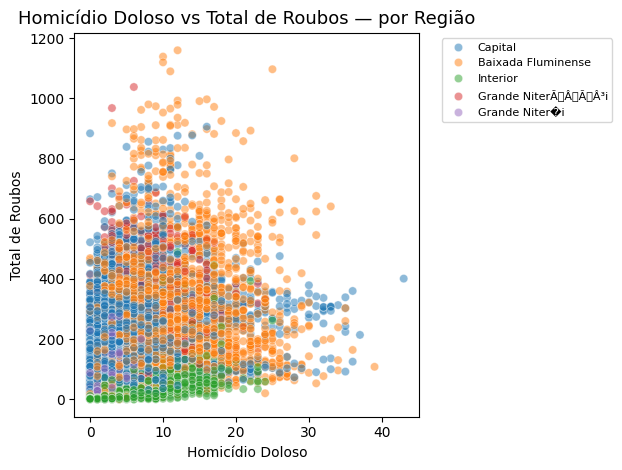

In [ ]:
# Relação entre homicídio doloso e total de roubos, colorido por região
sns.scatterplot(x='hom_doloso', y='total_roubos', hue='regiao', data=df, alpha=0.5, palette='tab10')
plt.title('Homicídio Doloso vs Total de Roubos — por Região', fontsize=13)
plt.xlabel('Homicídio Doloso')
plt.ylabel('Total de Roubos')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6850/132175690.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='regiao', y='hom_doloso', data=df, palette='pastel')
/tmp/ipykernel_6850/132175690.py:7: UserWarning: Glyph 131 (\x83) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6850/132175690.py:7: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 131 (\x83) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


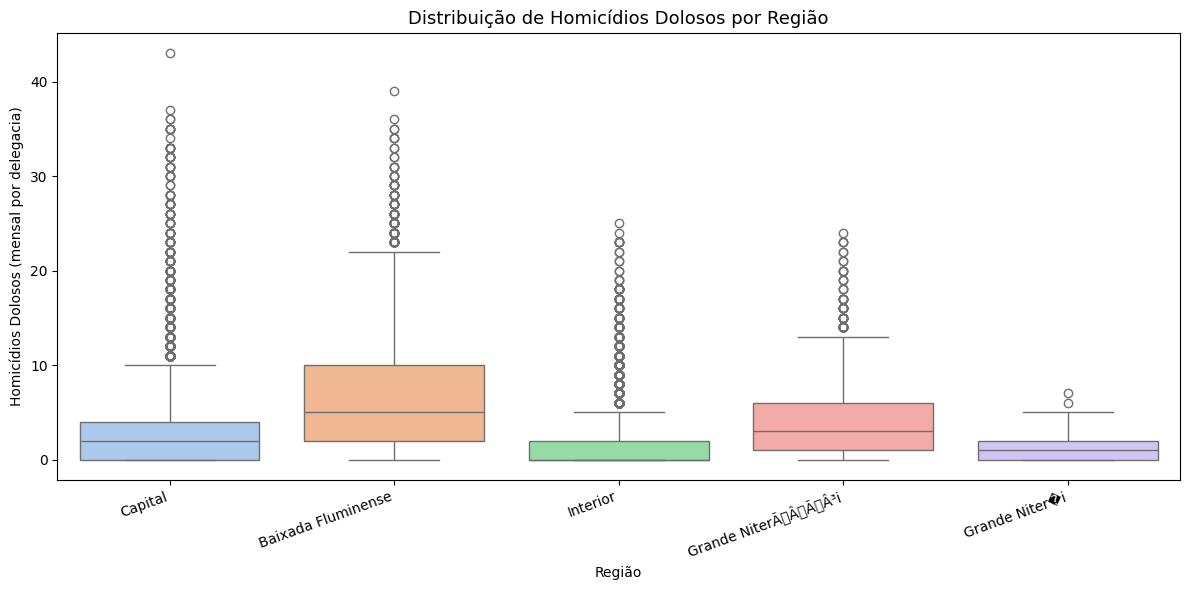

In [ ]:
#distribuição de homicidios dolosos por região
plt.figure(figsize=(12, 6))
sns.boxplot(x='regiao', y='hom_doloso', data=df, palette='pastel')
plt.title('Distribuição de Homicídios Dolosos por Região', fontsize=13)
plt.xlabel('Região')
plt.ylabel('Homicídios Dolosos (mensal por delegacia)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

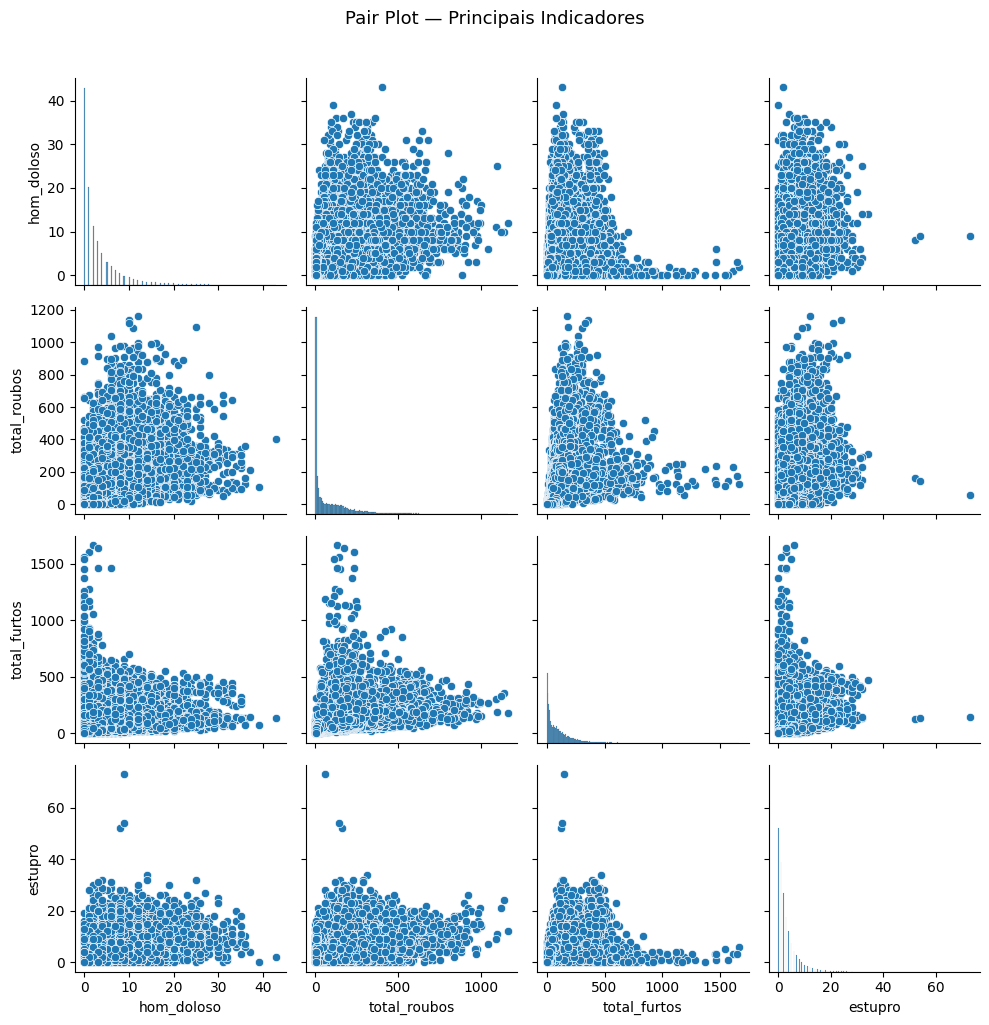

In [ ]:
# Pair plot das principais variáveis numéricas
cols_pairplot = ['hom_doloso', 'total_roubos', 'total_furtos', 'estupro']
sns.pairplot(df[cols_pairplot].dropna())
plt.suptitle('Pair Plot — Principais Indicadores', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

A evolução temporal é um dos achados mais interessantes deste dataset. Os homicídios dolosos caíram consistentemente de 2003 até 2024, saindo de mais de 6.600 por ano para menos de 3.000, uma redução expressiva ao longo de duas décadas. Os roubos, por sua vez, tiveram uma trajetória diferente: cresceram até 2017/2018, atingindo o pico, e depois caíram de forma abrupta com a pandemia em 2020, sem voltar ao nível anterior.

Os furtos apresentam comportamento inverso ao dos roubos nos últimos anos: enquanto os roubos caem, os furtos voltam a crescer após 2022, possivelmente indicando uma mudança no perfil das ocorrências.

No scatter plot, é possível ver que a relação entre homicídios e roubos não é linear, há delegacias com muitos roubos e poucos homicídios (tipicamente na Capital, zonas comerciais) e delegacias com muitos homicídios e poucos roubos (zonas periféricas). O box plot por região confirma que a Baixada Fluminense tem a maior mediana e dispersão de homicídios por registro.

###Correlação e Heatmap

In [ ]:
# Matriz de correlação
df_corr = df[cols_principais].dropna()
df_corr.corr()

,hom_doloso,cvli,letalidade_violenta,total_roubos,total_furtos,estupro,trafico_drogas,registro_ocorrencias
hom_doloso,1.000000,0.995422,0.944553,0.511379,0.231690,0.523980,0.327677,0.497539
cvli,0.995422,1.000000,0.949749,0.524131,0.238571,0.526213,0.328388,0.506603
letalidade_violenta,0.944553,0.949749,1.000000,0.582828,0.245471,0.512813,0.334110,0.530969
total_roubos,0.511379,0.524131,0.582828,1.000000,0.529385,0.419163,0.201689,0.786669
total_furtos,0.231690,0.238571,0.245471,0.529385,1.000000,0.311037,0.144037,0.827959
estupro,0.523980,0.526213,0.512813,0.419163,0.311037,1.000000,0.354304,0.589296
trafico_drogas,0.327677,0.328388,0.334110,0.201689,0.144037,0.354304,1.000000,0.341585
registro_ocorrencias,0.497539,0.506603,0.530969,0.786669,0.827959,0.589296,0.341585,1.000000


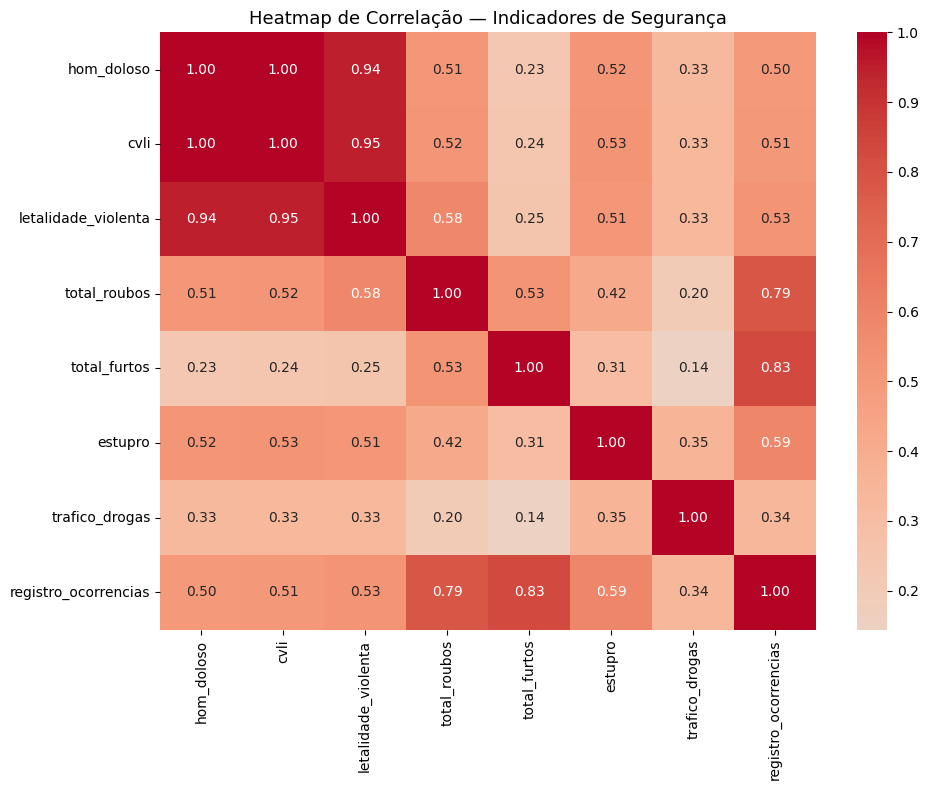

In [ ]:
# Heatmap de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Heatmap de Correlação — Indicadores de Segurança', fontsize=13)
plt.tight_layout()
plt.show()

###Conclusões

1.   O dataset cobre 24 anos (2003–2026) com 37.588 registros mensais por delegacia em 90 municípios, sem valores nulos nas colunas principais.
2.   Os dados de feminicidio só existem a partir de 2016, reflexo da mudança na legislaçã
3. Homicídios dolosos caíram pela metade entre 2003 e 2024, enquanto os roubos cresceram até 2017 e depois recuaram com a pandemia.
4. O Rio de Janeiro concentra o maior volume de roubos do estado, mas a Baixada Fluminense apresenta os índices mais preocupantes de homicídio por delegacia.
5. As correlações entre hom_doloso, cvli e letalidade_violenta são altíssimas por construção metodológica, enquanto total_roubos e total_furtos se correlacionam mais com o volume geral de registros da delegacia.